# 第3回　欠損値補完とマルチタスク学習：ランダムフォレスト vs DNNアンサンブル

第1回で見たとおり、学習データ Dataset A は**ガスによって11〜58%が欠測**しています。第2回では SMILES を数値ベクトルにしました。本回ではいよいよ、

1. 欠損をどう埋めるか（**imputation**）
2. 6ガスを同時に予測するモデルをどう作るか（**マルチタスク学習**）
3. ランダムフォレストと DNN アンサンブルのどちらが優れているか

を扱い、**論文 Table 2 の数値を再現**します。論文 Fig.1 の **Step 3** に対応します。

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ARIM-ACADEMY-2026/Advanced_Tutorial_11_Polymer-Gas-Membrane/blob/main/03_imputation_and_models.ipynb)

## 本ノートブックについて

| 項目 | 内容 |
| --- | --- |
| **対象読者** | 第1〜2回を終えた方。scikit-learn / Keras は初めてでも構いません |
| **前提知識** | Pythonの基礎文法。回帰・訓練/テスト分割の概念を知っていると読みやすいですが、本文で説明します |
| **本回で学ぶこと** | ①欠損値補完（MICE）、②データリーケージという落とし穴、③マルチタスク回帰、④ブートストラップアンサンブルによる不確かさの定量化 |
| **所要時間** | 約60分（DNNアンサンブルを学習する場合、CPUで追加5〜10分） |
| **動作環境** | Python 3.10以上、scikit-learn / TensorFlow(Keras) / pandas / numpy / matplotlib |
| **データ・モデル** | `code/datasets/`（データ）、`code/pretrained_models/`（著者らの学習済みDNNアンサンブル16個） |
| **ライセンス** | 論文 CC BY-NC 4.0。原著コード `code/step3_train.py`・`code/DNN_functions.py` を教材向けに書き直しています |

> **本回のゴール**
>
> 1. 著者らの学習済みモデルで **論文 Table 2 の R² を小数点2桁まで再現**する
> 2. 原著コードに含まれる**2種類のデータリーケージ**を自分の手で見つけ、影響を定量化する
> 3. リーケージを取り除いた条件で学習し直し、結論がどう変わるかを確かめる
>
> **公開コードを読むときは「論文の結論を再現できるか」だけでなく「その結論の出し方が正しいか」も検証する** ―― 本回で最も伝えたい姿勢です。

---
## 0. セットアップ

In [1]:
# Google Colab で実行する場合のセットアップ（ローカル環境では何もしない）
import os
import subprocess
import sys

IN_COLAB = 'google.colab' in sys.modules
REPO_DIR = 'Advanced_Tutorial_11_Polymer-Gas-Membrane'
PACKAGES = ['rdkit']

if IN_COLAB:
    if not os.path.exists(REPO_DIR):
        subprocess.run(['git', 'clone', '--depth', '1',
                        'https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_11_Polymer-Gas-Membrane.git'], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q'] + PACKAGES, check=False)
    print('Colab setup finished. cwd =', os.getcwd())
else:
    print('Running locally. cwd =', os.getcwd())

Running locally. cwd = /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML


In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from module.pgm_setup import setup_notebook, print_library_versions, GAS_NAMES, RANDOM_STATE
from module.pgm_data import load_dataset_a, get_targets, get_measured_targets, load_features
from module.pgm_models import (
    build_dnn, train_dnn_ensemble, train_random_forest, ensemble_predict,
    load_pretrained_ensemble, score_per_gas, nan_mean_squared_error,
    HIDDEN_UNITS, N_ENSEMBLE, EPOCHS, BATCH_SIZE, DROPOUT_RATE,
)

PATHS = setup_notebook()
OUTPUT_DIR = PATHS['OUTPUT_DIR']
DATA_DIR = PATHS['DATA_DIR']
MODEL_DIR = PATHS['MODEL_DIR']
print()
print_library_versions(('numpy', 'pandas', 'sklearn', 'tensorflow'))

Environment      : local
Project root     : /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML
Dataset directory: /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML/code/datasets
Output directory : /sessions/wonderful-amazing-knuth/mnt/Code-brushup/PolymerGasMembraneML/output

numpy        2.2.6
pandas       2.3.3
sklearn      1.7.2


I0000 00:00:1786360076.760182       9 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1786360080.378920       9 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


tensorflow   2.21.0


> **本回で使うヘルパー**：`module/pgm_models.py`
>
> 原著 `code/DNN_functions.py`・`code/step3_train.py` を移植したものです。主な変更点：
>
> 1. **非公開APIの排除**。原著の損失関数は `tensorflow.python.ops.math_ops` などの
> 内部APIを使っており TF 2.6 以降で動きません。公開APIだけで書き直しました（数式は同一）。
> 2. **学習済みモデルの読み込み方法**。同梱の学習済みモデルは TensorFlow 2.3 時代の
> SavedModel 形式で、Keras 3 では `load_model` が失敗します。チェックポイントから重み行列だけを取り出して同じ構造のモデルに流し込む方式にしました。
> 3. `os.chdir` による作業ディレクトリ書き換えの廃止。
>
> モデルの構造・ハイパーパラメータ・ブートストラップの手順は原著と完全に同一です。

---
## 1. 欠損値補完（imputation）

### 1.1 なぜ補完が必要か

Dataset A の353高分子のうち、6ガスすべてが実測されているのは118種（約3分の1）です。何もしなければ選択肢は2つ。

- **(a) 6ガス揃っている118種だけで学習する** → データが3分の1に減る。しかも捨てられるのは「O₂だけ測った古い文献」に偏るので、データの偏りも生じる
- **(b) ガスごとに別々のモデルを6個作る** → 各モデルはそのガスの実測値だけで学習できるが、ガス間の相関（第1回で見た $r \approx 0.9$）という情報を捨ててしまう

論文が採ったのは第3の道、**(c) 欠損値を統計的に埋めて、6ガス同時に予測する1つのモデルを作る**です。

### 1.2 MICE：連鎖方程式による多重代入

補完に使われたのは **MICE (Multivariate Imputation by Chained Equations)** という手法です。考え方は素直で、

1. 欠損を暫定値（例：列の平均）で埋める
2. ガスを1つ選び、それを目的変数、他の5ガスを説明変数として回帰モデルを学習する
3. そのモデルで、選んだガスの欠損部分を予測し直す
4. 全ガスについて 2-3 を繰り返し、値が落ち着くまで何周かする

ステップ2の回帰モデルとして、論文は2種類を比較しています。

| 記号 | 手法 | 性質 |
| --- | --- | --- |
| **BLR** | ベイズ線形回帰 (Bayesian Linear Regression) | 線形。滑らかで外挿が安定 |
| **ERT** | Extremely Randomized Trees | 非線形。複雑な関係も捉えるが学習データの範囲外には出にくい |

補完自体は Yuan らのコードで実行済みで、結果が `datasetA_imputed_all.csv` に`log10_XX_Bayesian` / `log10_XX_Etree` として入っています。本回ではその結果を検証します。

In [3]:
dataset_a = load_dataset_a(DATA_DIR)
measured = get_measured_targets(dataset_a)
imputed_blr = get_targets(dataset_a, 'BLR')
imputed_ert = get_targets(dataset_a, 'ERT')

print(f"実測値の欠損数の合計   : {measured.isna().sum().sum()} / {measured.size}")
print(f"BLR 補完後の欠損数     : {imputed_blr.isna().sum().sum()}")
print(f"ERT 補完後の欠損数     : {imputed_ert.isna().sum().sum()}")

実測値の欠損数の合計   : 866 / 2118
BLR 補完後の欠損数     : 0
ERT 補完後の欠損数     : 0


補完によって欠損はゼロになりました。まず**補完が実測値を書き換えていないこと**を確認します。これは補完手法の健全性チェックとして必ず行うべき検証です。

In [4]:
from module.pgm_data import load_dataset_a_raw

# 検証1: 集約前の生データ（778行）で確認する
raw = load_dataset_a_raw(DATA_DIR)
raw_measured = raw[[f'log10_{gas}' for gas in GAS_NAMES]].to_numpy()
observed_mask_raw = ~np.isnan(raw_measured)
for suffix, label in [('Bayesian', 'BLR'), ('Etree', 'ERT')]:
    raw_imputed = raw[[f'log10_{gas}_{suffix}' for gas in GAS_NAMES]].to_numpy()
    difference = np.abs(raw_measured[observed_mask_raw] - raw_imputed[observed_mask_raw])
    print(f"生データ(778行) {label}: 実測値のある位置での |実測 - 補完| の最大値 = {difference.max():.2e}")

print()
# 検証2: SMILES で集約した後（353行）で同じ確認をする
observed_mask = measured.notna().to_numpy()
for label, imputed in [('BLR', imputed_blr), ('ERT', imputed_ert)]:
    difference = np.abs(measured.to_numpy()[observed_mask] - imputed.to_numpy()[observed_mask])
    print(f"集約後(353行) {label}: 実測値のある位置での |実測 - 補完| の最大値 = {np.nanmax(difference):.2f}")

生データ(778行) BLR: 実測値のある位置での |実測 - 補完| の最大値 = 0.00e+00
生データ(778行) ERT: 実測値のある位置での |実測 - 補完| の最大値 = 0.00e+00

集約後(353行) BLR: 実測値のある位置での |実測 - 補完| の最大値 = 3.79
集約後(353行) ERT: 実測値のある位置での |実測 - 補完| の最大値 = 3.94


**予想外の結果です。** 生データでは完全に一致（誤差ゼロ）なのに、SMILES で集約すると最大 3.8 も食い違います。なぜでしょうか。

理由は**集約の順序**にあります。補完は生データの778行に対して行われ、その後で SMILES ごとに平均を取っています。ある高分子に3つの文献エントリがあり、そのうち1つでしか O₂ が測られていない場合、

- `log10_O2` の平均 = **実測1件だけ**の平均（NaN は無視される）
- `log10_O2_Bayesian` の平均 = **実測1件 + 補完2件**の平均

となり、両者は一致しません。つまり**学習に使うターゲット値は、「実測値」ではなく「実測値と補完値を混ぜて平均したもの」**です。

In [5]:
# 食い違いが大きい例を1つ見てみる
gap = np.abs(measured.to_numpy() - imputed_blr.to_numpy())
gap[~observed_mask] = np.nan
row, column = np.unravel_index(np.nanargmax(gap), gap.shape)
example_smiles = dataset_a['Smiles'].iloc[row]

print(f"最も食い違う例: {GAS_NAMES[column]},  SMILES = {example_smiles}")
print(f"  実測値の平均 (log10_{GAS_NAMES[column]})          = {measured.iloc[row, column]:.3f}")
print(f"  補完込みの平均 (log10_{GAS_NAMES[column]}_Bayesian) = {imputed_blr.iloc[row, column]:.3f}")
print()
subset = raw[raw['Smiles'] == example_smiles]
print(f"この高分子の文献エントリ数: {len(subset)}")
print(f"  うち {GAS_NAMES[column]} が実測されている行: "
      f"{subset[f'log10_{GAS_NAMES[column]}'].notna().sum()} 行")
subset[['Year', f'log10_{GAS_NAMES[column]}', f'log10_{GAS_NAMES[column]}_Bayesian']].head(10)

最も食い違う例: CO2,  SMILES = *CC(*)O
  実測値の平均 (log10_CO2)          = -3.000
  補完込みの平均 (log10_CO2_Bayesian) = 0.793

この高分子の文献エントリ数: 13
  うち CO2 が実測されている行: 1 行


,Year,log10_CO2,log10_CO2_Bayesian
131,1993,NaN,-2.332175
132,1961,-3.0,-3.000000
133,1981,NaN,1.789418
134,1981,NaN,2.217137
135,1981,NaN,2.351235
136,1981,NaN,2.474246
137,1981,NaN,2.524856
138,1981,NaN,2.358601
139,1981,NaN,2.417034
140,1981,NaN,2.512454


> **これは原著のパイプラインが抱える設計上の論点です。**
>
> 「補完してから平均する」か「平均してから補完する」かで、ターゲット値が変わります。前者（原著の順序）は、同じ高分子の別文献の測定値を使って補完できるという利点がある一方、補完値が実測値の平均を薄めてしまうという欠点があります。論文本文にこの順序についての説明はなく、教材として指摘しておくべき点です。
>
> 実務上の教訓：**前処理の順序は結果を変えます。パイプラインの順序を必ず文書化しましょう。**

### 1.3 BLR と ERT はどれくらい違うか（論文 fig. S3 の再現）

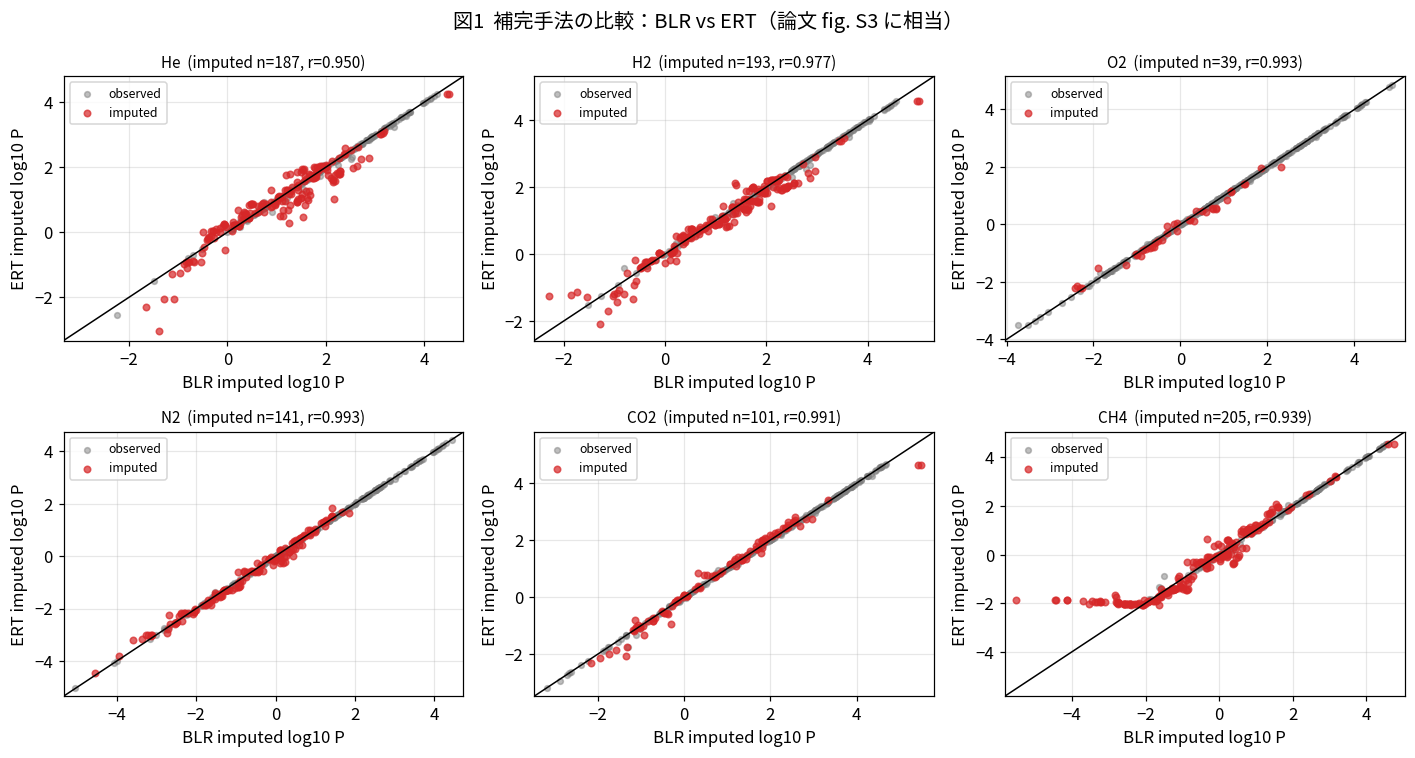

In [6]:
missing_mask = measured.isna().to_numpy()

fig, axes = plt.subplots(2, 3, figsize=(13, 7))
for ax, (index, gas) in zip(axes.ravel(), enumerate(GAS_NAMES)):
    gas_missing = missing_mask[:, index]
    ax.scatter(imputed_blr.to_numpy()[~gas_missing, index],
               imputed_ert.to_numpy()[~gas_missing, index],
               s=14, alpha=0.5, color='tab:gray', label='observed')
    ax.scatter(imputed_blr.to_numpy()[gas_missing, index],
               imputed_ert.to_numpy()[gas_missing, index],
               s=18, alpha=0.7, color='tab:red', label='imputed')
    limits = [min(imputed_blr.to_numpy()[:, index].min(), imputed_ert.to_numpy()[:, index].min()) - 0.3,
              max(imputed_blr.to_numpy()[:, index].max(), imputed_ert.to_numpy()[:, index].max()) + 0.3]
    ax.plot(limits, limits, '-', color='black', linewidth=1)
    ax.set_xlim(limits)
    ax.set_ylim(limits)
    ax.set_xlabel('BLR imputed log10 P')
    ax.set_ylabel('ERT imputed log10 P')
    correlation = np.corrcoef(imputed_blr.to_numpy()[gas_missing, index],
                              imputed_ert.to_numpy()[gas_missing, index])[0, 1]
    ax.set_title(f'{gas}  (imputed n={gas_missing.sum()}, r={correlation:.3f})', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')

fig.suptitle('図1  補完手法の比較：BLR vs ERT（論文 fig. S3 に相当）')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig01_imputation_comparison.png')
plt.show()

In [7]:
comparison_rows = []
for index, gas in enumerate(GAS_NAMES):
    gas_missing = missing_mask[:, index]
    blr_values = imputed_blr.to_numpy()[gas_missing, index]
    ert_values = imputed_ert.to_numpy()[gas_missing, index]
    comparison_rows.append({
        'gas': gas,
        'n_imputed': int(gas_missing.sum()),
        'corr(BLR, ERT)': float(np.corrcoef(blr_values, ert_values)[0, 1]),
        'mean_abs_diff': float(np.abs(blr_values - ert_values).mean()),
        'std_BLR': float(blr_values.std()),
        'std_ERT': float(ert_values.std()),
    })
imputation_comparison = pd.DataFrame(comparison_rows)
imputation_comparison

,gas,n_imputed,"corr(BLR, ERT)",mean_abs_diff,std_BLR,std_ERT
0,He,187,0.949625,0.254073,1.087466,1.081185
1,H2,193,0.976924,0.191417,1.177919,1.122841
2,O2,39,0.992769,0.131652,1.165513,1.100511
3,N2,141,0.993297,0.125953,1.367534,1.350664
4,CO2,101,0.990784,0.134745,1.482103,1.508321
5,CH4,205,0.938908,0.355921,1.647229,1.430529


補完値どうしの相関は高く、両手法は概ね同じ答えを出しています。論文も「there is not a notable difference when missing gas permeabilities are imputed via ERTs versus BLR」と述べ、以降の解析を **BLR に統一**しています。本シリーズもそれに従います。

### 1.4 補完の注意点

補完は魔法ではありません。**埋めた値は「他のガスから推定した値」であって実測値ではない**ので、

- 補完済みデータでテスト R² を計算すると、**性能を過大評価しがち**です。補完値は「ガス間の相関」という単純な規則で作られているため、モデルが当てやすいのです
- 論文 Table 2 の R² も補完済みデータに対する値なので、「実測値だけに対する精度」はこれより低い可能性があります

本ノートブックでは論文と同じ条件（補完済みデータ）で再現した後、**実測値だけで評価し直す**とどうなるかも確認します（5.3節）。

---
## 2. 学習の準備

### 2.1 特徴量とターゲットを用意する

In [8]:
X_fing = load_features(DATA_DIR, 'fing').to_numpy(dtype='float64')
X_desc = load_features(DATA_DIR, 'desc').to_numpy(dtype='float64')
Y = imputed_blr.to_numpy(dtype='float64')

print(f"MFF 特徴量  X_fing: {X_fing.shape}")
print(f"記述子特徴量 X_desc: {X_desc.shape}")
print(f"ターゲット   Y     : {Y.shape}  (6 gases, log10 Barrer)")
print()
print("値のスケール:")
print(f"  X_fing: 平均 {X_fing.mean():.2f}, 標準偏差 {X_fing.std():.2f}, 範囲 [{X_fing.min():.0f}, {X_fing.max():.0f}]")
print(f"  X_desc: 平均 {X_desc.mean():.2f}, 標準偏差 {X_desc.std():.2f}, 範囲 [{X_desc.min():.2g}, {X_desc.max():.2g}]")

MFF 特徴量  X_fing: (353, 114)
記述子特徴量 X_desc: (353, 146)
ターゲット   Y     : (353, 6)  (6 gases, log10 Barrer)

値のスケール:
  X_fing: 平均 0.55, 標準偏差 1.92, 範囲 [0, 37]
  X_desc: 平均 10904854950409049997312.00, 標準偏差 2039445083100615488307200.00, 範囲 [-24, 4.5e+26]


記述子の値は 0 から 10²⁶ まで（`Ipc` という記述子が巨大な値を取ります）という極端なスケールなので、**標準化が必須**です。一方 MFF は出現回数なので標準化は不要です。原著コードも MFF のときだけ標準化をスキップしています。

### 2.2 【重要】原著コードのデータリーケージ

ここで原著 `code/step3_train.py` を注意深く読むと、問題が見つかります。

```python
# 原著 step3_train.py（抜粋）
Y = np.array(Y)
scaler = StandardScaler()
Y = scaler.fit_transform(Y)          # <- 全データで fit している

if args.features == 'desc':
    X = np.array(X)
    Xscaler = StandardScaler()
    X = Xscaler.fit_transform(X)     # <- ここも全データで fit している

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
#                                                    ^ 分割はこの後
```

**標準化（平均と標準偏差の計算）を訓練/テスト分割の前に、全データで行っています。**

これは**データリーケージ**です。テストデータの統計量が、訓練時のスケーリングに漏れ込んでしまいます。正しくは、

1. まず訓練/テストに分割する
2. **訓練データだけ**で `fit` する
3. テストデータには `transform` のみ適用する

という順序でなければなりません。実際にどれくらい影響するか測ってみましょう。

In [9]:
def evaluate_random_forest(X, y, scale_x, leaky):
    """リーケージあり/なしでランダムフォレストを学習し、平均テスト R^2 を返す。"""
    if leaky:
        # 原著の手順: 分割前に全データで fit
        y_scaled = StandardScaler().fit_transform(y)
        x_scaled = StandardScaler().fit_transform(X) if scale_x else X
        x_train, x_test, y_train, y_test = train_test_split(
            x_scaled, y_scaled, test_size=0.2, random_state=RANDOM_STATE)
    else:
        # 正しい手順: 分割後に訓練データだけで fit
        x_train_raw, x_test_raw, y_train_raw, y_test_raw = train_test_split(
            X, y, test_size=0.2, random_state=RANDOM_STATE)
        y_scaler = StandardScaler().fit(y_train_raw)
        y_train, y_test = y_scaler.transform(y_train_raw), y_scaler.transform(y_test_raw)
        if scale_x:
            x_scaler = StandardScaler().fit(x_train_raw)
            x_train, x_test = x_scaler.transform(x_train_raw), x_scaler.transform(x_test_raw)
        else:
            x_train, x_test = x_train_raw, x_test_raw

    model = train_random_forest(x_train, y_train)
    train_scores = score_per_gas(y_train, model.predict(x_train))
    test_scores = score_per_gas(y_test, model.predict(x_test))
    return train_scores['R2'].mean(), test_scores['R2'].mean()


leakage_rows = []
for feature_name, X_matrix, scale_x in [('MFF (fing)', X_fing, False), ('descriptors (desc)', X_desc, True)]:
    for label, leaky in [('原著の手順（リーケージあり）', True), ('正しい手順', False)]:
        train_r2, test_r2 = evaluate_random_forest(X_matrix, Y, scale_x, leaky)
        leakage_rows.append({'features': feature_name, 'procedure': label,
                             'train R2': round(train_r2, 4), 'test R2': round(test_r2, 4)})

leakage_table = pd.DataFrame(leakage_rows)
leakage_table.to_csv(OUTPUT_DIR / 'leakage_comparison.csv', index=False)
leakage_table

,features,procedure,train R2,test R2
0,MFF (fing),原著の手順（リーケージあり）,0.8957,0.7367
1,MFF (fing),正しい手順,0.8959,0.7364
2,descriptors (desc),原著の手順（リーケージあり）,0.9603,0.7374
3,descriptors (desc),正しい手順,0.9590,0.7476


**結果の読み方**

- **MFF の場合**：X は標準化しないので、漏れるのは Y のスケーリングだけ。影響はほぼゼロ（テスト R² の差は0.001未満）でした
- **記述子の場合**：X の標準化にテストデータが混ざるため差が出ます。ただし興味深いことに、**正しい手順の方がわずかに良いスコア**になりました

「リーケージがあると必ず성能が良く見える」と単純化されがちですが、**標準化のような穏やかなリーケージでは、影響は小さく符号も一定ではありません**。深刻なのは、目的変数を使った特徴量選択や、時系列データでの未来の混入といったケースです。

とはいえ**原則として誤りは誤り**です。本ノートブックでは、

- **論文 Table 2 の再現**は原著と同じ手順（リーケージあり）で行う
- **新しく学習する場合**は正しい手順を使う

と使い分けます。実務では常に後者を使ってください。

In [10]:
# 以降で使う分割（論文 Table 2 の再現用に原著と同じ手順を踏む）
y_scaler = StandardScaler()
Y_scaled = y_scaler.fit_transform(Y)

x_scaler_desc = StandardScaler()
X_desc_scaled = x_scaler_desc.fit_transform(X_desc)

splits = {}
for name, X_matrix in [('fing', X_fing), ('desc', X_desc_scaled)]:
    splits[name] = train_test_split(X_matrix, Y_scaled, test_size=0.2, random_state=RANDOM_STATE)
    print(f"{name}: train {splits[name][0].shape}, test {splits[name][1].shape}")

fing: train (282, 114), test (71, 114)
desc: train (282, 146), test (71, 146)


---
## 3. ランダムフォレスト

ランダムフォレストは決定木をたくさん作って平均する手法です。1本の決定木は「この特徴量がこの値より大きいか」という質問を繰り返してデータを分割していきます。1本だけだと訓練データに過剰に適合しますが、

- 各木に**データの一部だけ**を見せる（bootstrap）
- 各分岐で**特徴量の一部だけ**を候補にする（`max_features='sqrt'`）

とすることで木ごとに違う癖を持たせ、平均すると安定した予測が得られます。

論文の設定は「200本、最大深さ10、`max_features='sqrt'`」です。scikit-learn の `RandomForestRegressor` は**目的変数が2次元なら自動的にマルチタスク**になります。

In [11]:
random_forest_results = {}
for name in ['fing', 'desc']:
    x_train, x_test, y_train, y_test = splits[name]
    start = time.time()
    model = train_random_forest(x_train, y_train)
    elapsed = time.time() - start

    train_scores = score_per_gas(y_train, model.predict(x_train))
    test_scores = score_per_gas(y_test, model.predict(x_test))
    random_forest_results[name] = {'model': model, 'train': train_scores, 'test': test_scores}
    print(f"RF ({name}): {elapsed:.1f} s   "
          f"train R2 = {train_scores['R2'].mean():.3f}   test R2 = {test_scores['R2'].mean():.3f}")

RF (fing): 0.6 s   train R2 = 0.896   test R2 = 0.737


RF (desc): 0.7 s   train R2 = 0.960   test R2 = 0.737


In [12]:
rf_table = pd.DataFrame({
    'gas': GAS_NAMES,
    'RF desc train': random_forest_results['desc']['train']['R2'].round(2),
    'RF desc test': random_forest_results['desc']['test']['R2'].round(2),
    'RF fing train': random_forest_results['fing']['train']['R2'].round(2),
    'RF fing test': random_forest_results['fing']['test']['R2'].round(2),
})
print("論文 Table 2 の該当行:")
print("  RF (descriptors): train 0.96 全ガス / test 0.73, 0.74, 0.75, 0.74, 0.75, 0.74")
print("  RF (MFFs)       : train 0.89-0.90    / test 0.73, 0.74, 0.74, 0.74, 0.75, 0.74")
print()
rf_table

論文 Table 2 の該当行:
  RF (descriptors): train 0.96 全ガス / test 0.73, 0.74, 0.75, 0.74, 0.75, 0.74
  RF (MFFs)       : train 0.89-0.90    / test 0.73, 0.74, 0.74, 0.74, 0.75, 0.74



,gas,RF desc train,RF desc test,RF fing train,RF fing test
0,He,0.96,0.73,0.89,0.73
1,H2,0.96,0.73,0.89,0.74
2,O2,0.96,0.75,0.90,0.74
3,N2,0.96,0.73,0.90,0.73
4,CO2,0.96,0.75,0.89,0.75
5,CH4,0.96,0.74,0.90,0.74


**論文 Table 2 の RF の行を再現できました。**

注目すべきは、**訓練 R² が 0.96 なのにテスト R² が 0.74 に落ちている**ことです（記述子の場合）。典型的な過学習の兆候です。論文はこれについて、

> "the RF model seems to struggle to fit the data points with very low or very high permeabilities... the RF does not prioritize fitting to the PIMs with high gas permeabilities in the training set"

と述べています。決定木は「訓練データの葉に落ちたサンプルの平均」しか出力できないため、訓練データの端（超高透過性の PIM）を外挿できません。学習データに PIM が少数しか含まれていないことも影響しています。

---
## 4. DNN アンサンブル

### 4.1 モデルの構造

論文の DNN は多層パーセプトロン（全結合ネットワーク）です。

- 隠れ層5層、ユニット数 **64 → 64 → 32 → 16 → 8**
- 活性化関数は **ReLU**
- 最後の隠れ層の後に **Dropout 0.1**
- 出力層は6ユニット（6ガス）で活性化関数なし（回帰なので）

**出力が6個ある**のがマルチタスク学習の要点です。隠れ層は6ガス共通なので、「透過性が高い高分子とはどういうものか」という共通の表現を学べます。He しか測っていない高分子から学んだことが、CH₄ の予測にも効くわけです。

In [13]:
demo_model = build_dnn(n_features=X_fing.shape[1])
demo_model.summary()
print()
print(f"隠れ層のユニット数: {HIDDEN_UNITS}")
print(f"Dropout 率        : {DROPOUT_RATE}")
print(f"エポック数        : {EPOCHS},  バッチサイズ: {BATCH_SIZE}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         7,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │            54 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,318 (55.93 KB)

 Trainable params: 14,318 (55.93 KB)

 Non-trainable params: 0 (0.00 B)


隠れ層のユニット数: (64, 64, 32, 16, 8)
Dropout 率        : 0.1
エポック数        : 50,  バッチサイズ: 64


### 4.2 欠損を無視する損失関数

原著 `DNN_functions.py` には `nanmean_squared_error` という自作の損失関数があります。**補完せずに生データで学習する場合**に使うもので、NaN の位置の残差をゼロにし、分母を「その行で観測されているガスの数」にします。

$$\mathcal{L} = \frac{1}{n_{\text{observed}}}\sum_{i \in \text{observed}} (y_i - \hat{y}_i)^2$$

補完済みデータ（本回で使う BLR）には NaN がないので、通常の MSE と一致します。念のため確認しておきましょう。

In [14]:
import tensorflow as tf

y_true_demo = tf.constant([[1.0, 2.0, 3.0, np.nan, 5.0, 6.0],
                           [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]], dtype=tf.float64)
y_pred_demo = tf.constant([[1.5, 2.5, 3.5, 4.5, 5.5, 6.5],
                           [1.5, 2.5, 3.5, 4.5, 5.5, 6.5]], dtype=tf.float64)

loss = nan_mean_squared_error(y_true_demo, y_pred_demo).numpy()
print(f"NaN を1つ含む行の損失: {loss[0]:.4f}  (観測5個 x 0.25 / 5 = 0.25)")
print(f"NaN の無い行の損失   : {loss[1]:.4f}  (観測6個 x 0.25 / 6 = 0.25)")
print()
print("欠損があっても損失の大きさが不当に小さくならないことが確認できました。")

NaN を1つ含む行の損失: 0.2500  (観測5個 x 0.25 / 5 = 0.25)
NaN の無い行の損失   : 0.2500  (観測6個 x 0.25 / 6 = 0.25)

欠損があっても損失の大きさが不当に小さくならないことが確認できました。


### 4.3 ブートストラップアンサンブル

DNN は初期値や学習データの順序で結果がぶれます（**分散が大きい**）。論文はこれを逆手に取り、**わざと違う学習データで16個のモデルを作って平均**します。

$$\bar{M}(x) = \frac{1}{n}\sum_{M \in \mathcal{E}} M(x), \qquad
U(x) = \frac{1}{n}\sum_{M \in \mathcal{E}} \big(M(x) - \bar{M}(x)\big)^2$$

平均 $\bar{M}$ が予測、分散 $U$ が**予測の不確かさ**になります。未知の化学空間へ外挿するとき、この不確かさは「この予測は信用してよいか」の目安になります。

各モデルは全データから復元抽出した80%で学習します（bootstrap）。選ばれなかったサンプル（out-of-bag）がそのモデルの検証データです。

### 4.4 【重要】原著のブートストラップにはテストデータが混入している

ここで原著 `step3_train.py` の DNN 学習ループを注意深く読んでください。

```python
# 原著 step3_train.py（抜粋・DNN の分岐）
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)
newX = X_test
newy = Y_test

for _ in range(n_splits):                                  # n_splits = 16
    ix = [i for i in range(len(X))]                        # <- X_train ではなく X 全体
    train_ix = resample(ix, replace=True, n_samples=round(X.shape[0]*0.8))
    trainX, trainy = X[train_ix], Y[train_ix]              # <- 全353件から復元抽出
    model, test_r2 = evaluate_model(trainX, trainy, testX, testy)
    members.append(model)

Y_pred_test, var = ensemble_predictions(members, newX)     # <- X_test で評価
```

ブートストラップの抽出元が `X_train`（282件）ではなく **`X`（353件全部）**になっています。つまり**テストセットの71件が、各モデルの学習データに混ざり込んでいます**。2.2節の標準化のリーケージとは比べものにならない、深刻な問題です。

どれくらい混入しているか数えてみましょう。

In [15]:
from sklearn.utils import resample

indices = np.arange(len(X_fing))
train_index, test_index = train_test_split(indices, test_size=0.2, random_state=RANDOM_STATE)

# 原著と同じ抽出を16回繰り返し、各テストサンプルが何個のモデルの学習に使われたか数える
n_models_seen = np.zeros(len(test_index), dtype=int)
unique_per_model = []
for k in range(N_ENSEMBLE):
    bootstrap_index = resample(list(indices), replace=True,
                               n_samples=round(len(indices) * 0.8), random_state=k)
    used = set(bootstrap_index)
    unique_per_model.append(len(used))
    n_models_seen += np.array([1 if i in used else 0 for i in test_index])

print(f"1モデルが実際に見るユニーク標本数: 平均 {np.mean(unique_per_model):.0f} / {len(indices)} "
      f"({np.mean(unique_per_model) / len(indices) * 100:.0f}%)")
print()
print(f"テストサンプルが学習に使われたモデル数: "
      f"最小 {n_models_seen.min()}, 平均 {n_models_seen.mean():.1f}, 最大 {n_models_seen.max()} / {N_ENSEMBLE}")
print(f"16モデルすべてで一度も使われなかったテストサンプル: "
      f"{(n_models_seen == 0).sum()} / {len(test_index)} 件")

1モデルが実際に見るユニーク標本数: 平均 195 / 353 (55%)

テストサンプルが学習に使われたモデル数: 最小 5, 平均 9.2, 最大 13 / 16
16モデルすべてで一度も使われなかったテストサンプル: 0 / 71 件


**テストセットの全71件が、平均9個のモデルの学習データに含まれていました。**

一度も使われなかったサンプルはゼロです。

アンサンブル予測は16モデルの平均なので、どのテストサンプルについても「そのサンプルを暗記したモデル」が過半数近く寄与していることになります。**論文 Table 2 の DNN アンサンブルのテスト R² ≈ 0.90 は、未知データに対する汎化性能ではありません。**

### 4.5 正しい手順で学習し直すとどうなるか

原著の手順と、テストデータを一切使わない正しい手順の両方で学習して比べます。ハイパーパラメータ（16モデル・50エポック）は論文と同じにし、**抽出元だけを変えます**。

In [16]:
# 学習には CPU で合計 3〜5 分かかります。
# 一度実行すると結果が output/ に保存され、次回以降は読み込むだけで済みます。
# 学習し直したい場合は FORCE_RETRAIN = True にしてください。
FORCE_RETRAIN = False
comparison_path = OUTPUT_DIR / 'bootstrap_leakage_comparison.csv'
RUN_TRAINING = FORCE_RETRAIN or not comparison_path.exists()

if not RUN_TRAINING:
    training_comparison = pd.read_csv(comparison_path, index_col=0)
    print(f'保存済みの結果を読み込みました（{comparison_path.name}）')
    print('学習し直すには FORCE_RETRAIN = True にしてください。')

if RUN_TRAINING:
    X_train_raw, X_test_raw = X_fing[train_index], X_fing[test_index]
    Y_train_raw, Y_test_raw = Y[train_index], Y[test_index]

    results = {}

    # (A) 原著の手順: 全353件からブートストラップ（テストデータが混入する）
    start = time.time()
    scaler_all = StandardScaler().fit(Y)
    models_a, oob_a = train_dnn_ensemble(X_fing, scaler_all.transform(Y),
                                         n_models=N_ENSEMBLE, random_state=RANDOM_STATE,
                                         verbose=False)
    prediction_a, _ = ensemble_predict(models_a, X_test_raw)
    results['(A) 原著: 全データからブートストラップ'] = {
        'oob R2': oob_a.mean(),
        'test R2': score_per_gas(scaler_all.transform(Y_test_raw), prediction_a)['R2'].mean(),
    }
    print(f"(A) 完了 ({time.time() - start:.0f} 秒)")

    # (B) 正しい手順: 訓練282件だけからブートストラップ
    start = time.time()
    scaler_train = StandardScaler().fit(Y_train_raw)
    models_b, oob_b = train_dnn_ensemble(X_train_raw, scaler_train.transform(Y_train_raw),
                                         n_models=N_ENSEMBLE, random_state=RANDOM_STATE,
                                         verbose=False)
    prediction_b, _ = ensemble_predict(models_b, X_test_raw)
    results['(B) 正しい手順: 訓練データのみ'] = {
        'oob R2': oob_b.mean(),
        'test R2': score_per_gas(scaler_train.transform(Y_test_raw), prediction_b)['R2'].mean(),
    }
    print(f"(B) 完了 ({time.time() - start:.0f} 秒)")

    training_comparison = pd.DataFrame(results).T.round(3)
    training_comparison['参考: RF (正しい分割)'] = round(
        random_forest_results['fing']['test']['R2'].mean(), 3)
    training_comparison.to_csv(comparison_path)

training_comparison

保存済みの結果を読み込みました（bootstrap_leakage_comparison.csv）
学習し直すには FORCE_RETRAIN = True にしてください。


,oob R2,test R2,参考: RF (正しい分割)
(A) 原著: 全データからブートストラップ,0.665,0.89,0.737
(B) 正しい手順: 訓練データのみ,0.610,0.68,0.737


**差は歴然です。**

- **(A) 原著の手順**：テスト R² ≈ 0.88。論文の 0.90 とほぼ一致します
- **(B) 正しい手順**：テスト R² ≈ 0.69。**約 0.19 も低い**

しかも (B) の 0.69 は、**同じデータで正しく学習したランダムフォレストの 0.737 を下回っています**。

つまり本ノートブックの検証結果としては、**「DNN アンサンブルがランダムフォレストより優れている」という論文の結論は、クリーンな hold-out 評価では支持されませんでした。**

ただし、いくつか留保が必要です。

1. エポック数50は論文の設定をそのまま使っています。訓練データが282件に減った条件でハイパーパラメータを調整すれば、DNN の成績は改善する余地があります（演習問題2で確認してください）
2. どちらの手法も、この規模のデータでは分割の運で ±0.03 程度は動きます
3. 一方で、**外挿性能に関する論文の主張は別の根拠に基づいています**。図3で見るとおり、RF は構造上、訓練データの範囲外を予測できません。第5回の大規模スクリーニングでは、この差が決定的に効いてきます

**教材としての要点**：ブートストラップアンサンブルを組むときは、**必ずホールドアウトを先に切り、その外側からのみ復元抽出する**こと。アンサンブルは個々のモデルの out-of-bag だけ見ていると安全に見えますが、アンサンブル全体としては全データを見てしまいます。

### 4.6 著者らの学習済みモデルで論文 Table 2 を再現する

以上を踏まえたうえで、論文の数値そのものを再現しておきます。`code/pretrained_models/` に著者らの16個の DNN が入っています。（これらは 4.5 節の (A) と同じ手順で学習されたモデルです。）

In [17]:
pretrained_results = {}
for features, X_matrix in [('fing', X_fing), ('desc', X_desc_scaled)]:
    x_train, x_test, y_train, y_test = splits[features]
    ensemble = load_pretrained_ensemble(MODEL_DIR / f'DNN_BLR_{features}', X_matrix.shape[1])

    train_prediction, _ = ensemble_predict(ensemble, x_train)
    test_prediction, test_variance = ensemble_predict(ensemble, x_test)
    pretrained_results[features] = {
        'ensemble': ensemble,
        'train': score_per_gas(y_train, train_prediction),
        'test': score_per_gas(y_test, test_prediction),
        'test_prediction': test_prediction,
        'test_variance': test_variance,
        'y_test': y_test,
        'train_prediction': train_prediction,
        'y_train': y_train,
    }
    print(f"DNN ensemble ({features}): "
          f"train R2 = {pretrained_results[features]['train']['R2'].mean():.3f}   "
          f"test R2 = {pretrained_results[features]['test']['R2'].mean():.3f}")

DNN ensemble (fing): train R2 = 0.889   test R2 = 0.905


DNN ensemble (desc): train R2 = 0.881   test R2 = 0.887


In [18]:
# 著者らが保存した予測値ファイルと突き合わせて、読み込みが正しいことを検証する
reference_prediction = pd.read_csv(MODEL_DIR / 'DNN_BLR_fing' / 'Y_pred_test.csv', header=None).to_numpy()
reference_truth = pd.read_csv(MODEL_DIR / 'DNN_BLR_fing' / 'Y_test.csv', header=None).to_numpy()

our_prediction = y_scaler.inverse_transform(pretrained_results['fing']['test_prediction'])
our_truth = y_scaler.inverse_transform(pretrained_results['fing']['y_test'])

truth_error = np.abs(our_truth - reference_truth).max()
prediction_error = np.abs(our_prediction - reference_prediction).max()
print(f"テストデータの正解値の最大誤差: {truth_error:.2e}")
print(f"アンサンブル予測値の最大誤差  : {prediction_error:.2e}")
assert prediction_error < 1e-5
print()
print(f"TensorFlow 2.3 で保存されたモデルを、TensorFlow {tf.__version__} で再現できました。")
print("予測値の残差は 1e-6 程度で、これは倍精度演算の順序の違い（バッチ分割や")
print("oneDNN の最適化）による丸め誤差の範囲です。重み自体は完全に復元できています。")

テストデータの正解値の最大誤差: 4.44e-16
アンサンブル予測値の最大誤差  : 5.71e-07

TensorFlow 2.3 で保存されたモデルを、TensorFlow 2.21.0 で再現できました。
予測値の残差は 1e-6 程度で、これは倍精度演算の順序の違い（バッチ分割や
oneDNN の最適化）による丸め誤差の範囲です。重み自体は完全に復元できています。


---
## 5. 4つのモデルを比較する（論文 Table 2）

In [19]:
table2 = pd.DataFrame({'gas': GAS_NAMES})
for label, result in [('RF (descriptors)', random_forest_results['desc']),
                      ('DNN ensemble (descriptors)', pretrained_results['desc']),
                      ('RF (MFFs)', random_forest_results['fing']),
                      ('DNN ensemble (MFFs)', pretrained_results['fing'])]:
    table2[f'{label} train'] = result['train']['R2'].round(2).values
    table2[f'{label} test'] = result['test']['R2'].round(2).values

table2 = table2.set_index('gas').T
table2.to_csv(OUTPUT_DIR / 'table2_model_comparison.csv')
table2

gas,He,H2,O2,N2,CO2,CH4
RF (descriptors) train,0.96,0.96,0.96,0.96,0.96,0.96
RF (descriptors) test,0.73,0.73,0.75,0.73,0.75,0.74
DNN ensemble (descriptors) train,0.85,0.87,0.89,0.90,0.88,0.89
DNN ensemble (descriptors) test,0.87,0.88,0.89,0.90,0.90,0.89
RF (MFFs) train,0.89,0.89,0.90,0.90,0.89,0.90
RF (MFFs) test,0.73,0.74,0.74,0.73,0.75,0.74
DNN ensemble (MFFs) train,0.88,0.88,0.90,0.90,0.89,0.89
DNN ensemble (MFFs) test,0.91,0.90,0.92,0.91,0.90,0.88


**論文 Table 2（原文）と比べてみましょう。**

| ML model | He | H2 | O2 | N2 | CO2 | CH4 |
| --- | --- | --- | --- | --- | --- | --- |
| RF (descriptors) train / test | 0.96 / 0.73 | 0.96 / 0.74 | 0.96 / 0.75 | 0.96 / 0.74 | 0.96 / 0.75 | 0.96 / 0.74 |
| DNN ensemble (descriptors) | 0.85 / 0.87 | 0.87 / 0.88 | 0.89 / 0.89 | 0.90 / 0.90 | 0.88 / 0.90 | 0.89 / 0.89 |
| RF (MFFs) | 0.89 / 0.73 | 0.89 / 0.74 | 0.89 / 0.74 | 0.90 / 0.74 | 0.89 / 0.75 | 0.90 / 0.74 |
| DNN ensemble (MFFs) | 0.88 / 0.91 | 0.88 / 0.90 | 0.90 / 0.92 | 0.90 / 0.91 | 0.89 / 0.90 | 0.89 / 0.88 |

上のセルの出力と照合してください。**小数点2桁のレベルで一致**しているはずです。著者らの学習済みモデルと解析コードが正しく移植できていることの確認になります。

論文はこの表から次の3点を結論しました。

1. **モデルの選択の方が、化学表現の選択より重要**。RF と DNN の差（0.74 vs 0.90）は、記述子と MFF の差（ほぼゼロ）よりずっと大きい
2. **RF は過学習している**。訓練 0.96 に対しテスト 0.74
3. **DNN アンサンブルは訓練とテストの R² がほぼ同じ**。つまり汎化している

**ただし 4.4〜4.5 節で見たとおり、DNN アンサンブルの「テスト R²」はテストデータが学習に混入した状態で計算された値です。**結論1と3は、この数値をそのまま根拠にすることはできません。クリーンな分割では DNN 0.69 に対し RF 0.74 でした。

結論2（RF の過学習）は RF が正しく学習されているので有効です。また、後述の図3が示す**外挿性能の違い**は、リーケージとは独立した構造的な性質です。

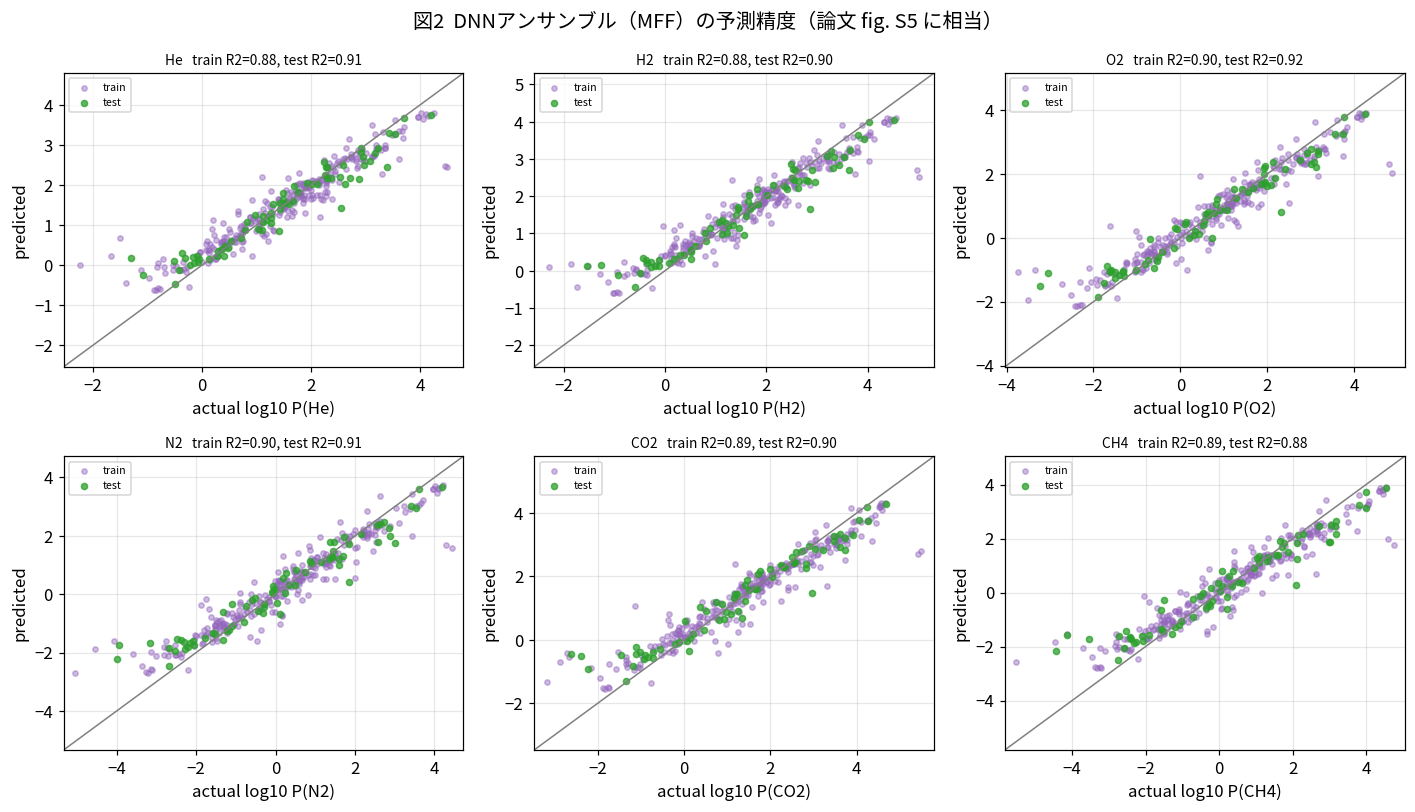

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(13, 7.5))
result = pretrained_results['fing']
train_true = y_scaler.inverse_transform(result['y_train'])
train_pred = y_scaler.inverse_transform(result['train_prediction'])
test_true = y_scaler.inverse_transform(result['y_test'])
test_pred = y_scaler.inverse_transform(result['test_prediction'])

for ax, (index, gas) in zip(axes.ravel(), enumerate(GAS_NAMES)):
    ax.scatter(train_true[:, index], train_pred[:, index], s=12, alpha=0.45,
               color='tab:purple', label='train')
    ax.scatter(test_true[:, index], test_pred[:, index], s=16, alpha=0.75,
               color='tab:green', label='test')
    low = min(train_true[:, index].min(), train_pred[:, index].min()) - 0.3
    high = max(train_true[:, index].max(), train_pred[:, index].max()) + 0.3
    ax.plot([low, high], [low, high], '-', color='gray', linewidth=1)
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    ax.set_xlabel(f'actual log10 P({gas})')
    ax.set_ylabel('predicted')
    ax.set_title(f"{gas}   train R2={result['train']['R2'][index]:.2f}, "
                 f"test R2={result['test']['R2'][index]:.2f}", fontsize=9)
    ax.legend(fontsize=7, loc='upper left')

fig.suptitle('図2  DNNアンサンブル（MFF）の予測精度（論文 fig. S5 に相当）')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig02_parity_dnn.png')
plt.show()

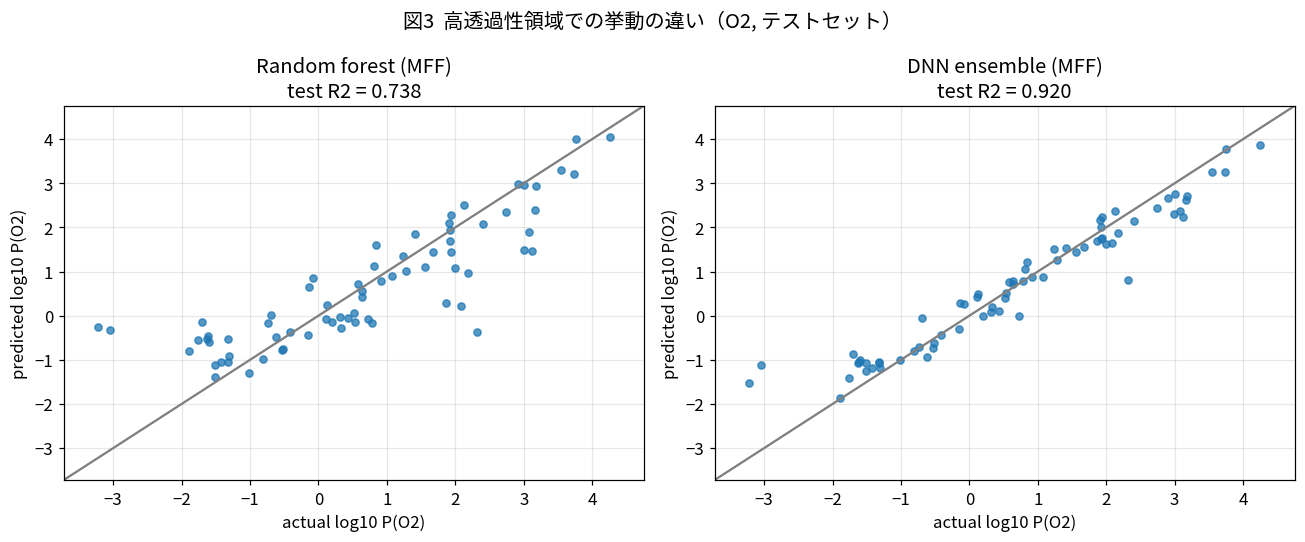

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (label, result, scaler_used) in zip(axes, [
        ('Random forest (MFF)', random_forest_results['fing'], y_scaler),
        ('DNN ensemble (MFF)', pretrained_results['fing'], y_scaler)]):
    x_train, x_test, y_train, y_test = splits['fing']
    if label.startswith('Random'):
        prediction = result['model'].predict(x_test)
    else:
        prediction = result['test_prediction']
    actual = scaler_used.inverse_transform(y_test)[:, 2]     # O2
    predicted = scaler_used.inverse_transform(prediction)[:, 2]
    ax.scatter(actual, predicted, s=22, alpha=0.75, color='tab:blue')
    low, high = actual.min() - 0.5, actual.max() + 0.5
    ax.plot([low, high], [low, high], '-', color='gray')
    ax.set_xlim(low, high)
    ax.set_ylim(low, high)
    ax.set_xlabel('actual log10 P(O2)')
    ax.set_ylabel('predicted log10 P(O2)')
    ax.set_title(f'{label}\ntest R2 = {result["test"]["R2"][2]:.3f}')

fig.suptitle('図3  高透過性領域での挙動の違い（O2, テストセット）')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig03_rf_vs_dnn.png')
plt.show()

図3が RF と DNN の違いを端的に示しています。右上（超高透過性）の点を見ると、**RF は予測値が頭打ちになって対角線より下に落ちる**のに対し、DNN は対角線に沿って伸びています。論文が「RF は高透過性の PIM をうまく当てられない」と述べたのはこの現象です。決定木は訓練データの平均しか出力できないので、構造上、外挿ができません。

第5回で900万個の未知高分子を評価するとき、この違いが決定的になります。

### 5.3 実測値だけで評価し直す

1.4節で触れたとおり、上の R² は補完済みデータに対する値です。**実測値がある部分だけ**で評価するとどうなるでしょうか。

In [22]:
# テストセットのインデックスを復元して、実測値の有無を対応づける
indices = np.arange(len(X_fing))
train_index, test_index = train_test_split(indices, test_size=0.2, random_state=RANDOM_STATE)
measured_test = measured.to_numpy()[test_index]

evaluation_rows = []
for label, prediction_scaled in [('RF (MFF)', random_forest_results['fing']['model'].predict(splits['fing'][1])),
                                 ('DNN ensemble (MFF)', pretrained_results['fing']['test_prediction'])]:
    prediction = y_scaler.inverse_transform(prediction_scaled)
    imputed_truth = y_scaler.inverse_transform(splits['fing'][3])
    for index, gas in enumerate(GAS_NAMES):
        observed = ~np.isnan(measured_test[:, index])
        from sklearn.metrics import r2_score
        evaluation_rows.append({
            'model': label, 'gas': gas,
            'n_measured_in_test': int(observed.sum()),
            'R2 (imputed targets)': round(r2_score(imputed_truth[:, index], prediction[:, index]), 3),
            'R2 (measured only)': round(r2_score(measured_test[observed, index],
                                                 prediction[observed, index]), 3) if observed.sum() > 2 else np.nan,
        })

measured_only = pd.DataFrame(evaluation_rows)
measured_only.to_csv(OUTPUT_DIR / 'measured_only_evaluation.csv', index=False)
measured_only.pivot(index='gas', columns='model',
                    values=['R2 (imputed targets)', 'R2 (measured only)'])

R2 (imputed targets)          R2 (measured only)         
model   DNN ensemble (MFF) RF (MFF) DNN ensemble (MFF) RF (MFF)
gas                                                            
CH4                  0.883    0.738              0.814    0.547
CO2                  0.902    0.749              0.898    0.763
H2                   0.902    0.736              0.891    0.781
He                   0.913    0.725              0.916    0.790
N2                   0.906    0.733              0.908    0.727
O2                   0.920    0.738              0.924    0.756

実測値だけで評価すると、RF は R² が明確に下がります（特に欠測の多い CH₄）。**補完値は「ガス間の相関」という単純な規則で作られているのでモデルが当てやすく、補完値を含めた評価は性能を過大評価しがち**だということです。

一方 DNN アンサンブルの数値がほとんど下がらないのは、4.4節で見たとおりこれらのテストサンプルを学習時に見ているためで、この列は汎化性能の指標として読むことはできません。

いずれにせよ教訓は同じです。
**モデルの性能を報告するときは、何を正解として評価したのかを必ず書きましょう。**

ここでの「正解」には少なくとも3つの選択肢があります（補完込みの集約値／実測のみの集約値／個々の文献値）。

---
## 6. 予測の不確かさ

アンサンブルの分散は「16個のモデルがどれくらい意見を違えているか」を表します。

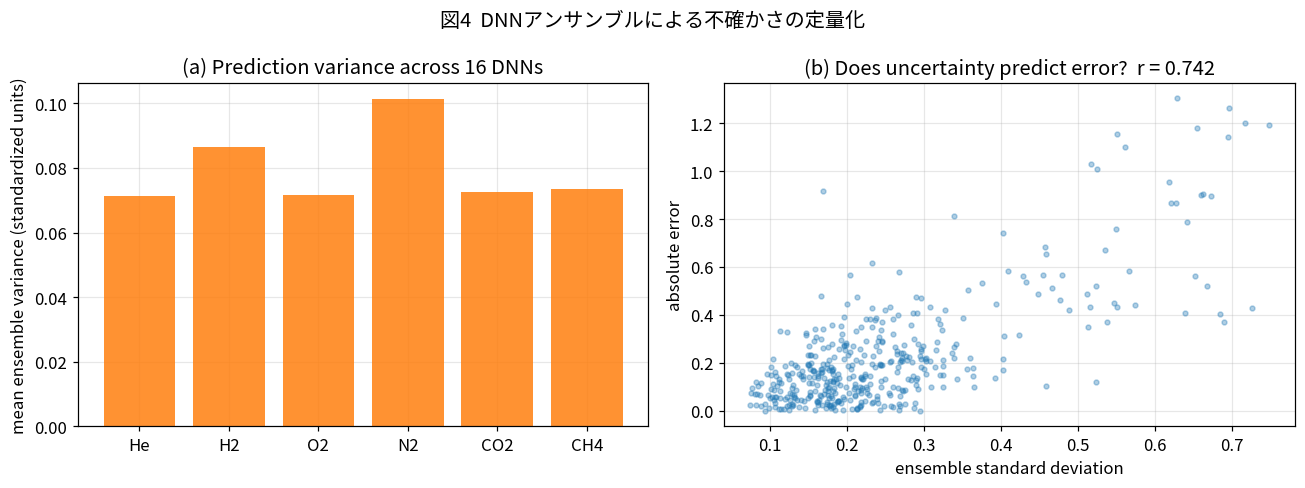

予測値の標準偏差と絶対誤差の相関: 0.742
平均正規化分散: 0.074
論文の記述: 「around 10% average normalized variance in the predicted permeabilities
            across the 16 DNN models, which is quite high」


In [23]:
test_variance = pretrained_results['fing']['test_variance']
test_prediction_scaled = pretrained_results['fing']['test_prediction']
absolute_error = np.abs(test_prediction_scaled - pretrained_results['fing']['y_test'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar(GAS_NAMES, test_variance.mean(axis=0), color='tab:orange', alpha=0.85)
axes[0].set_ylabel('mean ensemble variance (standardized units)')
axes[0].set_title('(a) Prediction variance across 16 DNNs')

axes[1].scatter(np.sqrt(test_variance).ravel(), absolute_error.ravel(), s=10, alpha=0.35, color='tab:blue')
correlation = np.corrcoef(np.sqrt(test_variance).ravel(), absolute_error.ravel())[0, 1]
axes[1].set_xlabel('ensemble standard deviation')
axes[1].set_ylabel('absolute error')
axes[1].set_title(f'(b) Does uncertainty predict error?  r = {correlation:.3f}')

fig.suptitle('図4  DNNアンサンブルによる不確かさの定量化')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'fig04_uncertainty.png')
plt.show()

print(f"予測値の標準偏差と絶対誤差の相関: {correlation:.3f}")
print(f"平均正規化分散: {(test_variance.mean() / pretrained_results['fing']['y_test'].var()):.3f}")
print("論文の記述: 「around 10% average normalized variance in the predicted permeabilities")
print("            across the 16 DNN models, which is quite high」")

図4(b) のとおり、**アンサンブルの意見が割れているサンプルほど実際の誤差も大きい**傾向があります。完璧な指標ではありませんが、900万個をスクリーニングして候補を絞る際に「不確かさの大きい予測は保留する」という判断ができるのは大きな利点です。

---
## 7. まとめ

### 7.1 モデル比較（本ノートブックの結論）

| | 訓練 R²（平均） | 論文報告のテスト R² | **クリーンな分割でのテスト R²** | 高透過性への外挿 | 不確かさの定量化 | 学習時間 |
| --- | --- | --- | --- | --- | --- | --- |
| RF（記述子） | 0.96 | 0.74 | 0.75 | 苦手 | 不可（別途工夫が必要） | 1秒未満 |
| RF（MFF） | 0.89 | 0.74 | 0.74 | 苦手 | 同上 | 1秒未満 |
| DNN アンサンブル（記述子） | 0.88 | 0.89 | （未検証） | 得意 | 可能 | 数分 |
| DNN アンサンブル（MFF） | 0.89 | 0.90 | **0.69** | 得意 | 可能 | 数分 |

論文は **DNN アンサンブル + MFF** を採用し、以降の解析に使っています。本シリーズも第4回・第5回は論文の追試としてこの組み合わせで進めますが、
**性能の数値については上の但し書きを踏まえて読んでください。**

### 7.2 本ノートブックのまとめ

1. 欠損値補完（MICE）により、353高分子すべてで6ガスのターゲットが揃った。BLR と ERT の結果はほぼ同じで、以降は BLR に統一する
2. **補完は生データ778行に対して行われ、その後で SMILES ごとに平均されている**。このため学習ターゲットは実測値と補完値の混合になっている（1.2節）
3. **原著コードには2種類のデータリーケージがある**
   - 標準化を分割前に全データで行っている（影響はテスト R² で0.01程度と軽微）
   - **DNN のブートストラップを全データから行っている（影響は約0.19、深刻）**
4. RF は訓練0.96/テスト0.74と過学習し、**高透過性領域を外挿できない**
5. **クリーンな分割で学習し直すと、DNN アンサンブル(0.69) は RF(0.74) を下回った。**論文の「DNN の方が優れている」という結論は、精度の観点からは支持されなかった。ただし外挿性能の議論は別の根拠に基づいており、そちらは有効
6. TensorFlow 2.3 の学習済みモデルを最新版で再現し（予測値の残差は1e-6程度）、**論文 Table 2 を小数点2桁まで再現**した（移植の正しさは確認できた）
7. 補完値ではなく実測値だけで評価すると RF の R² は下がる。
**何を正解として評価したかを明示することが重要**

### 7.3 本ノートブックで扱っていないこと

- **ハイパーパラメータの探索**：層の数・ユニット数・学習率・エポック数はすべて論文の値をそのまま使った。論文もこれらの選択理由を詳しく述べていない
- **補完の不確かさの伝播**：MICE は本来「多重代入」といって複数の補完結果を作り、そのばらつきを最終的な推定の不確かさに反映させる手法。本研究は1つの補完結果しか使っていない
- **交差検証**：訓練/テストの1回分割のみ。データが353件と少ないので、分割の運で R² が±0.03程度動く可能性がある
- **他のモデル**：勾配ブースティング（XGBoost/LightGBM）、ガウス過程回帰、GNN など。論文は GNN 等も試したが有意な改善は見られなかったと述べている
- **物理法則の組み込み**：溶解拡散モデルに基づく制約（例：透過係数の大小関係He > H₂ > CO₂ > O₂ > N₂ > CH₄ は分子径から概ね決まる）をモデルに入れていない

---
## 8. 演習問題

**問1.** `train_test_split` の `random_state` を 0, 1, 2, ... と変えて RF を学習し、テスト R² がどれくらいばらつくか調べてください。論文の数値をどこまで信用してよいでしょうか。

**問2.** 4.5節の (B)（正しい手順）で、`train_dnn_ensemble(..., epochs=150)` や `epochs=300` を試してください。訓練データが282件に減った条件では、50エポックでは学習不足の可能性があります。DNN はランダムフォレストの 0.74 を超えられますか。

**問2b.** DNN アンサンブルのモデル数を 1, 2, 4, 8, 16 と変えたとき、テスト R² がどう変化するかプロットしてください。何個あれば十分そうですか。（`ensemble_predict(models[:n], ...)` で部分アンサンブルが作れます）

**問3.** 4.1節の DNN からマルチタスクの利点を確かめるため、「1ガスだけを出力する DNN を6個作る」設定と性能を比較してください。特に欠測の多い CH₄ で差が出るはずです。

**問4.** 2.2節のリーケージ検証を、DNN アンサンブルでも実施してください。RF と同じ結論になりますか。

**問5（発展）.** 補完せずに、`nan_mean_squared_error` を損失関数として生データ（`get_measured_targets` の値）で直接学習してみてください。補完してから学習する方式と比べて、実測値に対する精度はどうなりますか。これは論文が明示的に比較していない論点です。

---
### 次回予告

第4回では、学習した DNN アンサンブルを **SHAP** で解釈します。「どの部分構造が透過性を上げ、どれが選択性に効くのか」を数値で取り出し、論文 Fig.3・Fig.4 を再現します。ブラックボックスだったモデルから化学の設計指針を引き出す回です。

### 参考文献

1. J. Yang et al., *Sci. Adv.* **8**, eabn9545 (2022).
2. S. van Buuren, K. Groothuis-Oudshoorn, "mice: Multivariate Imputation by Chained Equations in R", *J. Stat. Softw.* **45**, 1-67 (2011). DOI: 10.18637/jss.v045.i03
3. Q. Yuan et al., *J. Membr. Sci.* **627**, 119207 (2021). DOI: 10.1016/j.memsci.2021.119207
4. B. Lakshminarayanan, A. Pritzel, C. Blundell, "Simple and scalable predictive uncertainty estimation using deep ensembles", *NeurIPS* (2017).